In [1]:
import numpy as np

from s2fview import Gene, coverage_track, interactive_coverage_track

(<Figure size 2000x440 with 1 Axes>,
 <Axes: title={'center': 'Example coverage track'}, ylabel='Coverage'>)

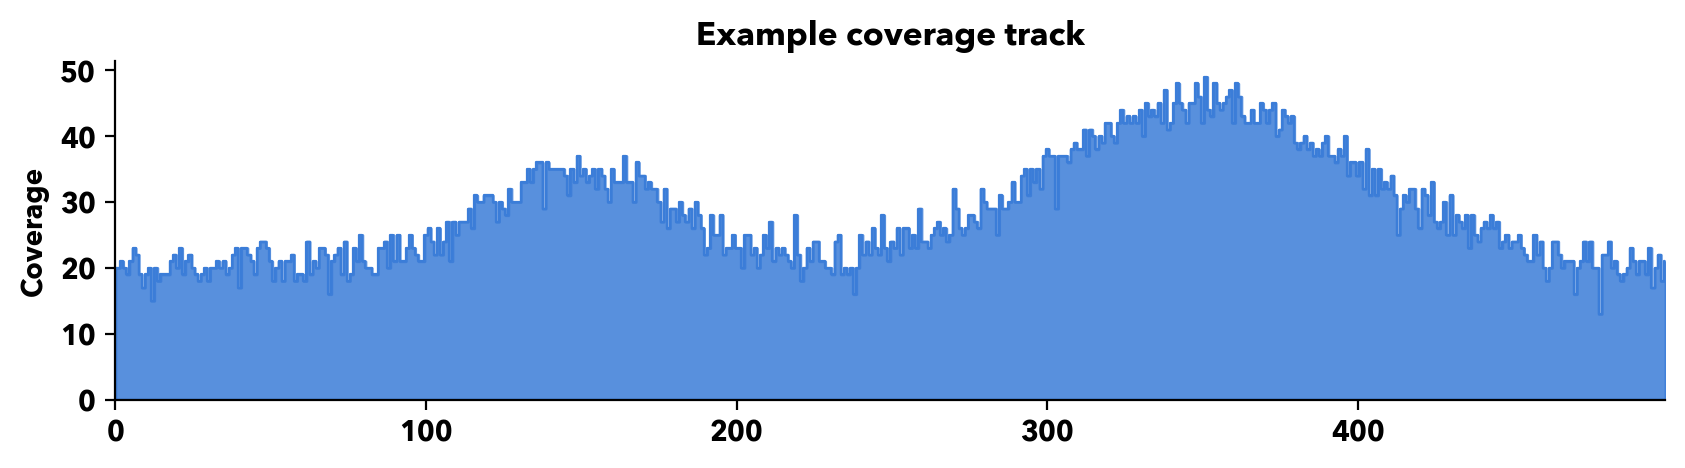

In [2]:
rng = np.random.default_rng(0)
length = 500
positions = np.arange(length)

signal = 20 + 15 * np.exp(-((positions - 150) ** 2) / (2 * 30**2))
signal += 25 * np.exp(-((positions - 350) ** 2) / (2 * 50**2))
coverage = np.maximum(0, signal + rng.normal(0, 2, size=length)).round().astype(int)

coverage_track(coverage, positions, title="Example coverage track")

(<Figure size 2000x630 with 2 Axes>,
 <Axes: title={'center': 'Coverage with gene track'}, ylabel='Coverage'>)

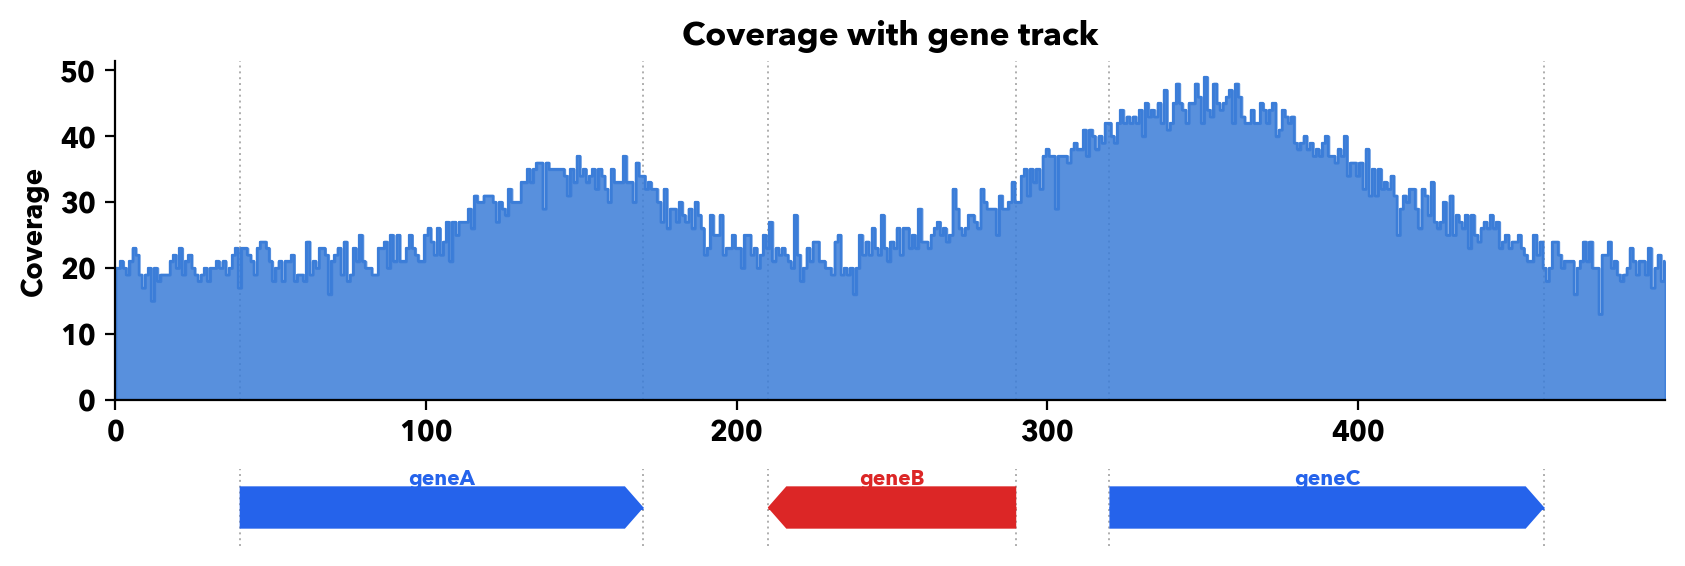

In [3]:
genes = [
    Gene(name="geneA", start=40, end=170, strand="+"),
    Gene(name="geneB", start=210, end=290, strand="-"),
    Gene(name="geneC", start=320, end=460, strand="+"),
]

coverage_track(coverage, positions, genes=genes, title="Coverage with gene track")

(<Figure size 2000x630 with 2 Axes>,
 <Axes: title={'center': 'Gene with introns & exons'}, ylabel='Coverage'>)

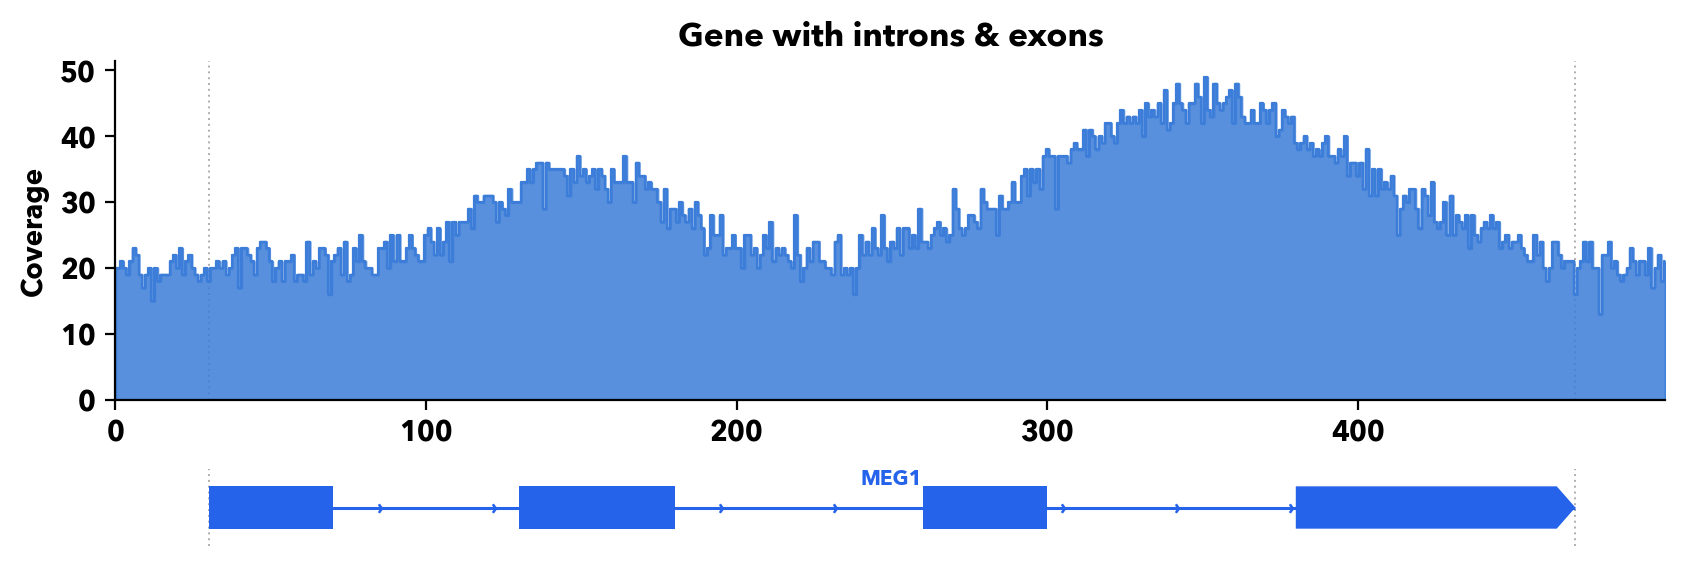

In [4]:
multi_exon_genes = [
    Gene(
        name="MEG1",
        start=30,
        end=470,
        strand="+",
        exons=((30, 70), (130, 180), (260, 300), (380, 470)),
    ),
]

coverage_track(
    coverage,
    positions,
    genes=multi_exon_genes,
    title="Gene with introns & exons",
)

(<Figure size 2000x770 with 2 Axes>,
 <Axes: title={'center': 'Overlapping genes (auto-stacked into lanes)'}, ylabel='Coverage'>)

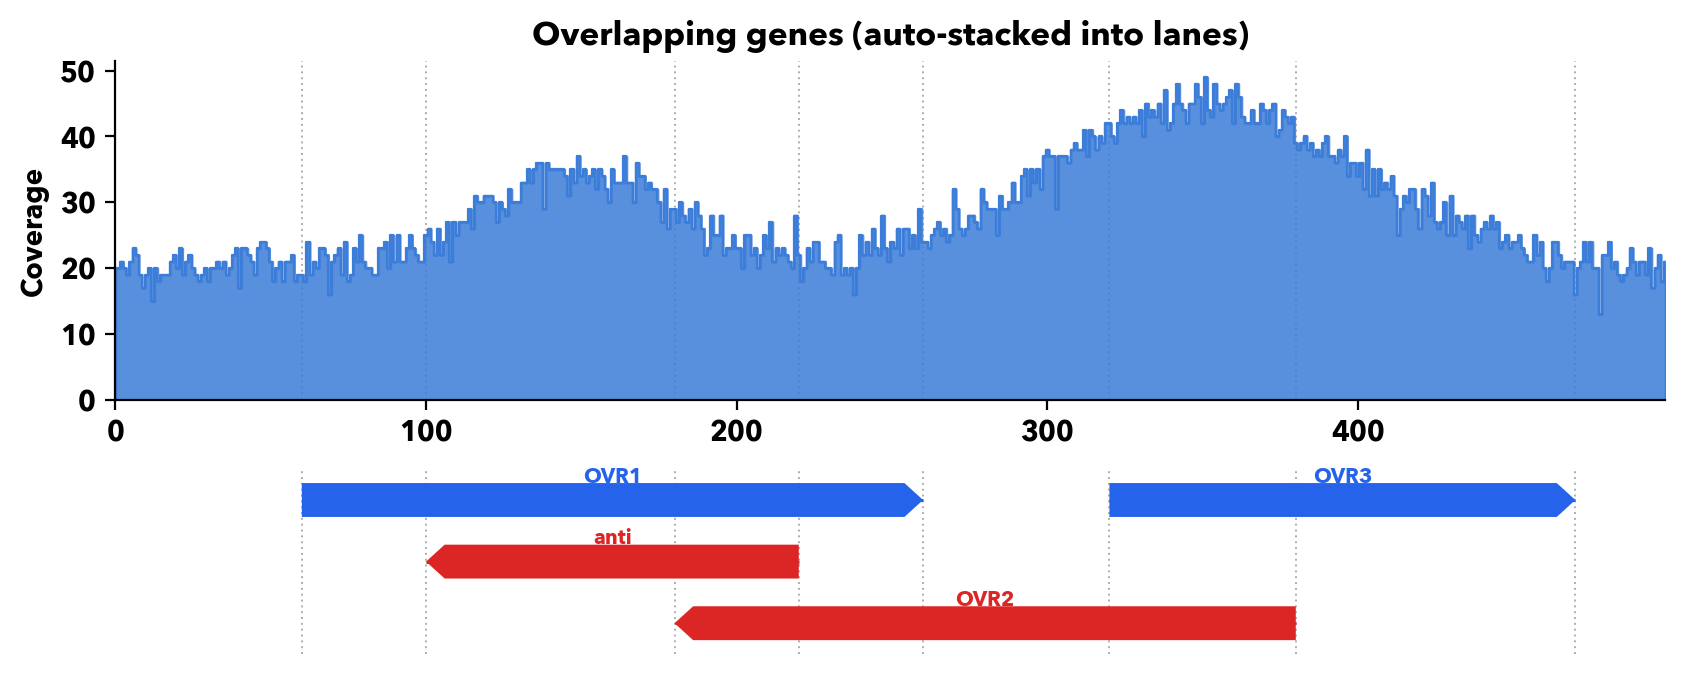

In [5]:
overlapping_genes = [
    Gene(name="OVR1", start=60, end=260, strand="+"),
    Gene(name="OVR2", start=180, end=380, strand="-"),
    Gene(name="OVR3", start=320, end=470, strand="+"),
    Gene(name="anti", start=100, end=220, strand="-"),
]

coverage_track(
    coverage,
    positions,
    genes=overlapping_genes,
    title="Overlapping genes (auto-stacked into lanes)",
)

(<Figure size 2000x770 with 2 Axes>,
 <Axes: title={'center': 'Mixed: overlapping, multi-exon, tiny genes'}, ylabel='Coverage'>)

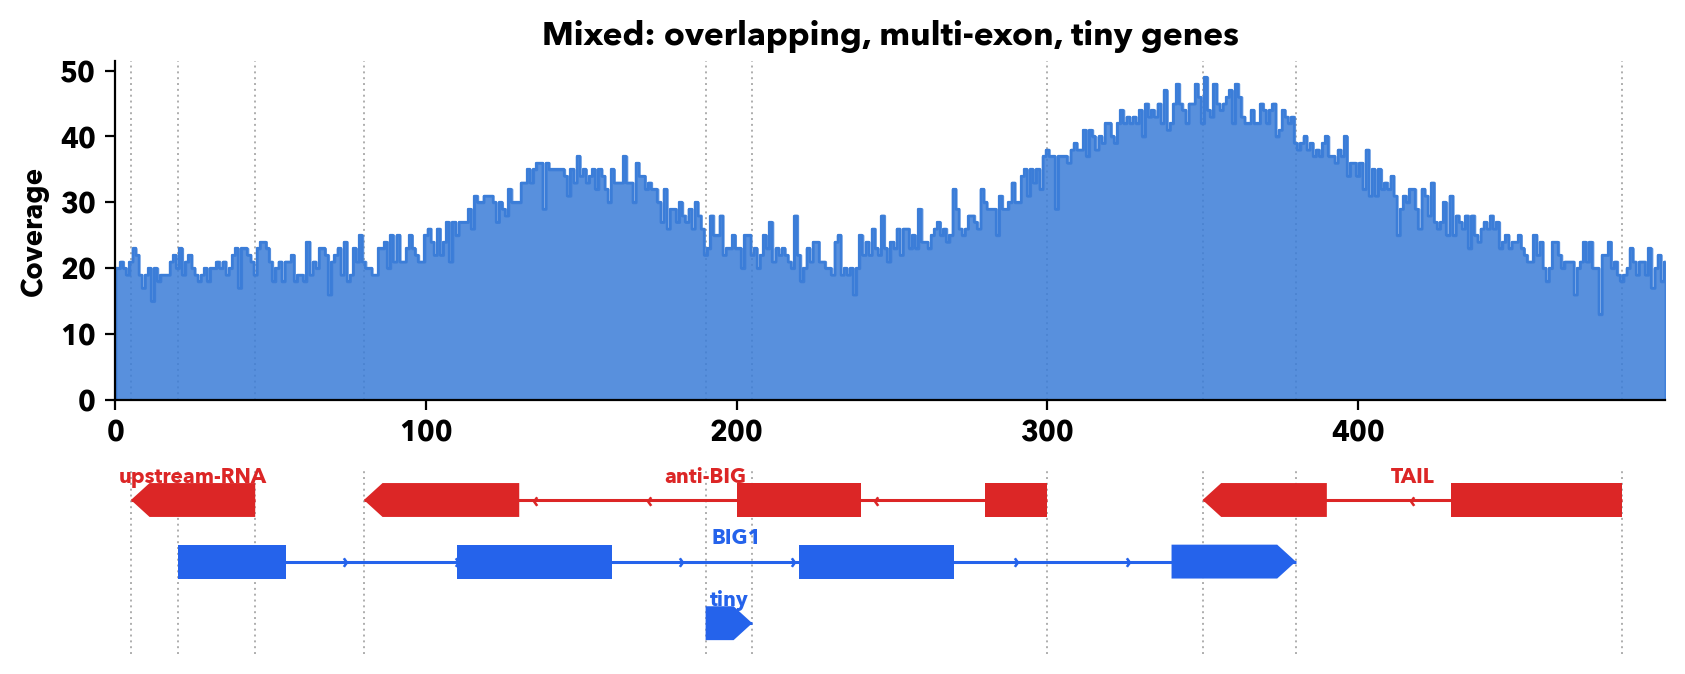

In [6]:
messy_genes = [
    Gene(
        name="BIG1",
        start=20,
        end=380,
        strand="+",
        exons=((20, 55), (110, 160), (220, 270), (340, 380)),
    ),
    Gene(
        name="anti-BIG",
        start=80,
        end=300,
        strand="-",
        exons=((80, 130), (200, 240), (280, 300)),
    ),
    Gene(name="tiny", start=190, end=205, strand="+"),
    Gene(
        name="TAIL",
        start=350,
        end=485,
        strand="-",
        exons=((350, 390), (430, 485)),
    ),
    Gene(name="upstream-RNA", start=5, end=45, strand="-"),
]

coverage_track(
    coverage,
    positions,
    genes=messy_genes,
    title="Mixed: overlapping, multi-exon, tiny genes",
)

## Interactive demo lives in its own notebook

For the IGV-style interactions (drag-to-zoom, double-click reset, hover
crosshair), open **`notebook_interactive.ipynb`**. The matplotlib widget
backend must be activated at the *start* of a notebook — mixing it in mid-way
after inline figures have been drawn is unreliable, so we keep the interactive
demo separate.